### Projeto Aplicado 

# 🧠 Projeto MaisVida Preditivo: Inteligência Artificial Aplicada ao Diagnóstico Situacional do Idoso


* **Autor:** Reinaldo Ríchardi Oliveira Galvão
* **Local e Data:** Pará de Minas - MG | Julho de 2026

### 🎯 Objetivo do Projeto
Desenvolver um protótipo funcional de *Machine Learning* treinado com a base de dados municipal para **classificar a probabilidade de risco clínico de diabetes e hipertensão** na população idosa, auxiliando no rastreio precoce e embasando a formulação de políticas públicas proativas.

### 💻 Escopo deste Notebook: Sprint 1 (Preparação e Exploração de Dados); Sprint 2 (Machine Learning); Sprint 3 (App Preditivo, Deploy e documentação)



---

In [1]:
import pandas as pd
import os

# Caminho relativo para o arquivo Excel
file_path = os.path.join("..", "..", "data", "Dados Completos - Fapam Pesquisa.xlsx")
xls = pd.ExcelFile(file_path)
print("Sheets:", xls.sheet_names)

df = pd.read_excel(file_path, sheet_name=xls.sheet_names[0])
print("\nColumns:", df.columns.tolist())
print("\nHead:\n", df.head())

Sheets: ['Sheet']

Columns: ['respondent_id', 'collector_id', 'date_created', 'date_modified', 'ip_address', 'email_address', 'first_name', 'last_name', 'custom_1', 'Nome do Entrevistador:', 'O(A) Sr(a) poderia me informar a sua data de nascimento?', 'Qual é o seu endereço?', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', ' Iniciais do entrevistado:', 'Qual UBS (Posto de saúde) o senhor(a) utiliza?', 'Idade no dia da entrevista ( ) anos', 'Qual das opções seguintes descreve melhor a sua cor?', 'Unnamed: 20', 'Sobre identidade de gênero, você se considera:', 'Qual sua orientação sexual:', 'Você pertence a alguma religião?', 'Qual a sua situação conjugal atual?', 'Há quantos anos o(a) Sr(a) mora neste município?', 'O(a) Sr(a) nasceu no Brasil?(Entrevistador: Caso a resposta seja “Não” é obrigatório informar o tempo em que está no Brasil no campo “com que idade se mudou”).', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'Qual seu sexo biológico?', 'Quantos filhos vivos o(a) Sr

In [2]:
# Sprint 1
# 1. Preparação e Exploração de Dados
# As variables dictated by the user's project:
# Idade (Idade no dia da entrevista ( ) anos)
# Sexo (Qual seu sexo biológico?)
# Hábitos Alimentares (Derived from frequency of consumption questions like 'Em geral, QUANTAS VEZES POR DIA o(a) Sr(a) costuma comer verduras ou legumes?' and 'Em geral, QUANTAS VEZES POR DIA o(a) Sr(a) costuma comer frutas?')
# Atividade Física (Derived from walking/moderate/vigorous questions)
# Uso de Tabaco (Atualmente o(a) Sr(a) fuma? E no passado, o(a) Sr(a) fumou?)
# Targets:
# Diabetes (Algum médico já lhe disse que o(a) Sr(a) tem diabetes (açúcar no sangue)?)
# Hipertensão (Algum médico já lhe disse que o(a) Sr(a) tem hipertensão arterial (pressão alta)?)

# Let's clean up and rename columns for clarity.
cols_to_keep = {
    'Idade no dia da entrevista ( ) anos': 'idade',
    'Qual seu sexo biológico?': 'sexo_biologico',
    'Em geral, QUANTAS VEZES POR DIA o(a) Sr(a) costuma comer verduras ou legumes?': 'verduras_freq',
    'Em geral, QUANTAS VEZES POR DIA o(a) Sr(a) costuma comer frutas?': 'frutas_freq',
    'Em quantos dias da última semana o(a) Sr(a) CAMINHOU por pelo menos 10 minutos contínuos em casa ou no trabalho, como forma de transporte para ir de um lugar para outro, por lazer, por prazer ou como forma de exercício?': 'caminhada_freq',
    'Em quantos dias da última semana, o(a) Sr(a) realizou ATIVIDADESMODERADAS por pelo menos 10 minutos contínuos?Atividades físicas MODERADAS: aquelas que precisam de algum esforço físico e que fazem respirar UM POUCO mais forte que o normal ou fazem o coração bater UM POUCO mais forte.Exemplos de atividades físicas moderadas: pedalar leve na bicicleta, nadar, dançar, fazer ginástica aeróbica leve, jogar vôlei recreativo, carregar pesos leves, fazer serviços domésticos na casa, no quintal ou no jardim como varrer, aspirar, cuidar do jardim etc. Não inclui caminhada.': 'atividade_moderada',
    'Em quantos dias da última semana, o(a) Sr(a) realizou ATIVIDADES VIGOROSAS por pelo menos 10 minutos contínuos?Atividades físicas VIGOROSAS: aquelas que precisam de um grande esforço físico e que fazem respirar MUITO mais forte que o normal ou fazem o coração bater MUITO mais forte.São exemplos de atividade física vigorosa: correr, fazer ginástica aeróbica, jogar futebol, pedalar rápido na bicicleta, jogar basquete, fazer serviços domésticos pesados em casa, no quintal ou cavoucar no jardim, carregar pesos etc.': 'atividade_vigorosa',
    'Para terminar esta seção, vou fazer algumas perguntas sobre fumo de cigarros industrializados, cigarros de palha ou de outros produtos do tabaco que são fumados, tais como charuto, cigarrilha, cachimbo, cigarros de cravo (ou de Bali), cigarros indianos (ou bidis) e narguilé (ou cachimbos d´água). Por favor, não responda sobre produtos de tabaco que não fazem fumaça como rapé e fumo de mascar. Não considerar cigarro eletrônicoAtualmente o(a) Sr(a) fuma? Se sim, perguntar se diariamente ou não.': 'fuma_atualmente',
    'E no passado, o(a) Sr(a) fumou?': 'fumou_passado',
    'Algum médico já lhe disse que o(a) Sr(a) tem diabetes (açúcar no sangue)?': 'diag_diabetes',
    'Algum médico já lhe disse que o(a) Sr(a) tem hipertensão arterial (pressão alta)?': 'diag_hipertensao'
}

df_clean = df[list(cols_to_keep.keys())].rename(columns=cols_to_keep)
print(df_clean.head())
print("\nMissing values:\n", df_clean.isnull().sum())

                 idade sexo_biologico            verduras_freq  \
0  Open-Ended Response       Response                 Response   
1                   61      Masculino          2 vezes por dia   
2                  100       Feminino  3 vezes ou mais por dia   
3                   61       Feminino            1 vez por dia   
4                   92       Feminino          2 vezes por dia   

               frutas_freq            caminhada_freq  \
0                 Response                  Response   
1            1 vez por dia  Quantos dias por semana?   
2  3 vezes ou mais por dia                Nenhum dia   
3            1 vez por dia  Quantos dias por semana?   
4            1 vez por dia  Quantos dias por semana?   

               atividade_moderada        atividade_vigorosa fuma_atualmente  \
0                        Response                  Response        Response   
1  Quantidade de dias por semana?  Quantos dias por semana?             Não   
2                      Nenhum

DATASET FINAL - RESUMO

Shape: 300 linhas × 9 colunas

Colunas: ['idade', 'sexo_biologico', 'habitos_alimentares', 'atividade_fisica', 'uso_tabaco', 'diag_diabetes', 'diag_hipertensao', 'diabetes_binary', 'hipertensao_binary']

PRIMEIROS 10 REGISTROS
    idade  sexo_biologico  habitos_alimentares  atividade_fisica  uso_tabaco  \
1      61               0                    2                 2           0   
2     100               1                    2                 0           0   
3      61               1                    2                 0           0   
4      92               1                    2                 0           0   
7      76               1                    2                 0           1   
8      93               1                    2                 0           1   
9     100               0                    2                 0           0   
10     75               1                    2                 0           1   
11     85               1    

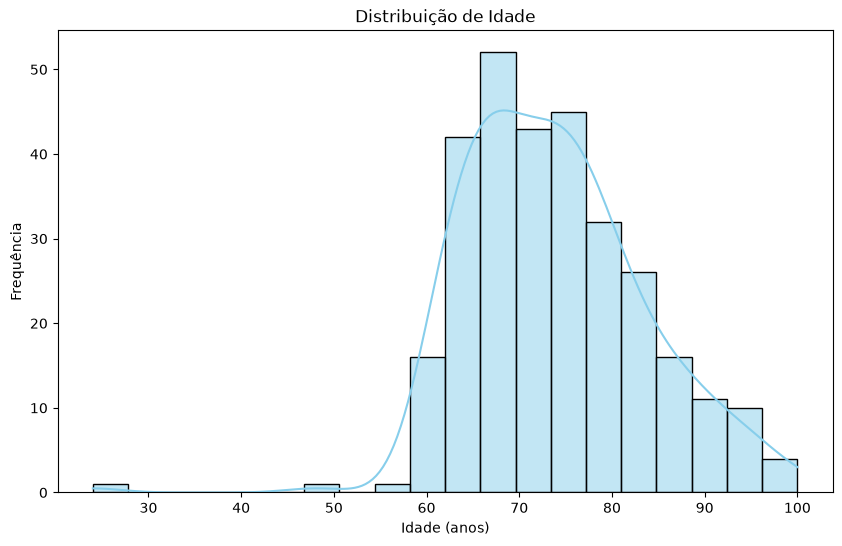

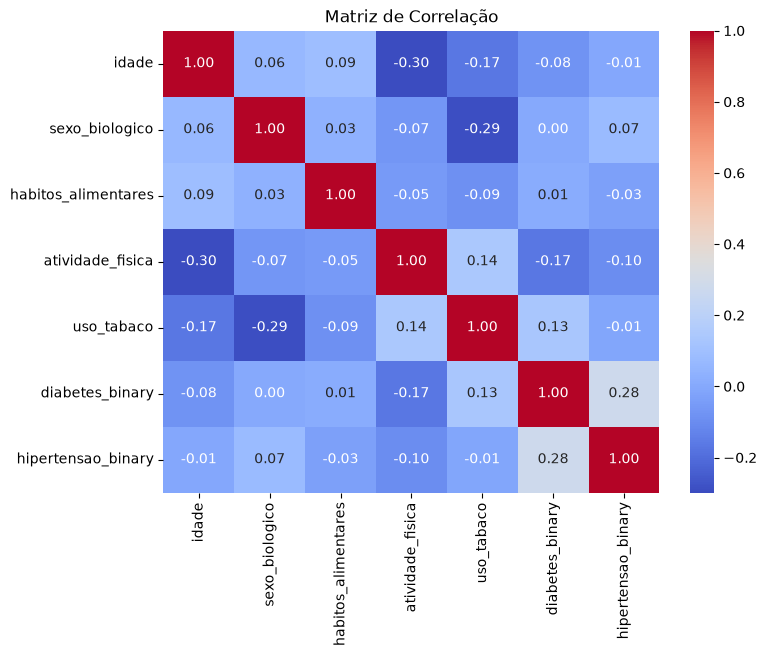

C:\Users\Reinaldo\AppData\Local\Temp\ipykernel_21060\4089093252.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(x='diabetes_binary', data=df_final, palette=['#6fa896', '#e8a382'])
C:\Users\Reinaldo\AppData\Local\Temp\ipykernel_21060\4089093252.py:120: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax1.set_xticklabels(['Não (0)', 'Sim (1)'])
C:\Users\Reinaldo\AppData\Local\Temp\ipykernel_21060\4089093252.py:126: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.countplot(x='hipertensao_binary', data=df_final, palette=['#6fa896', '#e8a382'])
C:\Users\Reinaldo\AppData

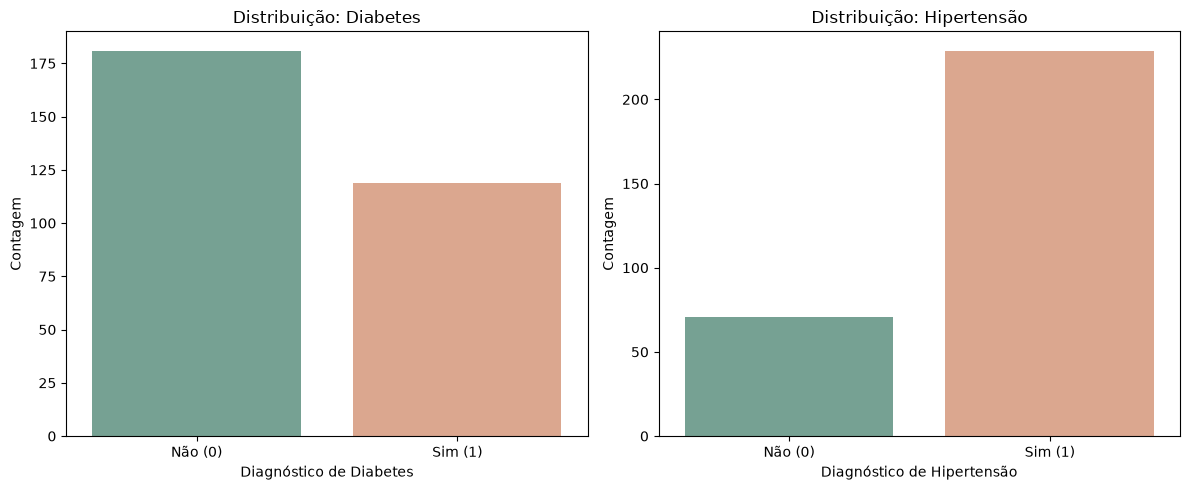


Imagens geradas e salvas com sucesso.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Drop the first metadata row (se ainda não foi feito)
if 0 in df_clean.index:
    df_clean = df_clean.drop(0)

# Drop missing values para os dados tratados
df_clean_processed = df_clean.dropna(subset=['idade', 'sexo_biologico', 'verduras_freq', 'frutas_freq', 'atividade_moderada', 'atividade_vigorosa', 'fuma_atualmente', 'fumou_passado', 'diag_diabetes', 'diag_hipertensao']).copy()

# 1. Idade
df_clean_processed['idade'] = pd.to_numeric(df_clean_processed['idade'], errors='coerce')
df_clean_processed = df_clean_processed.dropna(subset=['idade'])

# 2. Sexo_biologico (0=Masculino, 1=Feminino)
df_clean_processed['sexo_biologico'] = df_clean_processed['sexo_biologico'].apply(lambda x: 0 if 'Masculino' in str(x) else 1)

# 3. Habitos Alimentares (Heuristic: combined score from fruits and vegetables)
def map_food(x):
    x = str(x).lower()
    if 'nunca' in x or 'raramente' in x or 'esporadicamente' in x: return 0
    if 'semana' in x: return 1 # 1-4 times a week
    if 'dia' in x: return 2 # daily
    return 0

df_clean_processed['verduras_score'] = df_clean_processed['verduras_freq'].apply(map_food)
df_clean_processed['frutas_score'] = df_clean_processed['frutas_freq'].apply(map_food)
df_clean_processed['habitos_alimentares'] = ((df_clean_processed['verduras_score'] + df_clean_processed['frutas_score']) / 2).round().astype(int)

# 4. Atividade Física (Heuristic based on moderate/vigorous)
def map_activity(x):
    x = str(x).lower()
    if 'nenhum' in x or 'nunca' in x: return 0
    if '1 a 2' in x: return 1
    if '3 ou mais' in x or 'quantos' in x or 'quantidade' in x: return 2
    return 0

df_clean_processed['mod_score'] = df_clean_processed['atividade_moderada'].apply(map_activity)
df_clean_processed['vig_score'] = df_clean_processed['atividade_vigorosa'].apply(map_activity)
df_clean_processed['atividade_fisica'] = np.maximum(df_clean_processed['mod_score'], df_clean_processed['vig_score'])

# 5. Uso Tabaco
def map_tobacco(row):
    atual = str(row['fuma_atualmente']).lower()
    passado = str(row['fumou_passado']).lower()
    if 'sim' in atual: return 2
    if 'sim' in passado: return 1
    return 0

df_clean_processed['uso_tabaco'] = df_clean_processed.apply(map_tobacco, axis=1)

# Targets (Codificação binária: 0=Não, 1=Sim)
df_clean_processed['diabetes_binary'] = df_clean_processed['diag_diabetes'].apply(lambda x: 1 if 'Sim' in str(x) else 0)
df_clean_processed['hipertensao_binary'] = df_clean_processed['diag_hipertensao'].apply(lambda x: 1 if 'Sim' in str(x) else 0)

# Final Dataset - Incluindo features processadas E diagnósticos originais
df_final = df_clean_processed[[
    'idade', 
    'sexo_biologico', 
    'habitos_alimentares', 
    'atividade_fisica', 
    'uso_tabaco',
    'diag_diabetes',  # Diagnóstico original (texto)
    'diag_hipertensao',  # Diagnóstico original (texto)
    'diabetes_binary',  # Diagnóstico codificado (0/1)
    'hipertensao_binary'  # Diagnóstico codificado (0/1)
]].copy()

print("="*80)
print("DATASET FINAL - RESUMO")
print("="*80)
print(f"\nShape: {df_final.shape[0]} linhas × {df_final.shape[1]} colunas")
print(f"\nColunas: {df_final.columns.tolist()}")
print("\n" + "="*80)
print("PRIMEIROS 10 REGISTROS")
print("="*80)
print(df_final.head(10))
print("\n" + "="*80)
print("ESTATÍSTICAS DESCRITIVAS (Features Numéricas)")
print("="*80)
print(df_final[['idade', 'sexo_biologico', 'habitos_alimentares', 'atividade_fisica', 'uso_tabaco', 'diabetes_binary', 'hipertensao_binary']].describe())
print("\n" + "="*80)
print("DIAGNÓSTICOS - Distribuição Original (Texto)")
print("="*80)
print("\nDiabetes:")
print(df_final['diag_diabetes'].value_counts())
print("\nHipertensão:")
print(df_final['diag_hipertensao'].value_counts())
print("\n" + "="*80)
print("DIAGNÓSTICOS - Distribuição Codificada (0/1)")
print("="*80)
print("\nDiabetes (0=Não, 1=Sim):")
print(df_final['diabetes_binary'].value_counts())
print("\nHipertensão (0=Não, 1=Sim):")
print(df_final['hipertensao_binary'].value_counts())

# EDA Visualizations
plt.figure(figsize=(10, 6))
sns.histplot(df_final['idade'], bins=20, kde=True, color='skyblue')
plt.title('Distribuição de Idade')
plt.xlabel('Idade (anos)')
plt.ylabel('Frequência')
plt.savefig('dist_idade.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 6))
corr = df_final[['idade', 'sexo_biologico', 'habitos_alimentares', 'atividade_fisica', 'uso_tabaco', 'diabetes_binary', 'hipertensao_binary']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação')
plt.savefig('matriz_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()

# Gráficos dos targets com rótulos claros
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
ax1 = sns.countplot(x='diabetes_binary', data=df_final, palette=['#6fa896', '#e8a382'])
ax1.set_xticklabels(['Não (0)', 'Sim (1)'])
ax1.set_xlabel('Diagnóstico de Diabetes')
ax1.set_ylabel('Contagem')
plt.title('Distribuição: Diabetes')

plt.subplot(1, 2, 2)
ax2 = sns.countplot(x='hipertensao_binary', data=df_final, palette=['#6fa896', '#e8a382'])
ax2.set_xticklabels(['Não (0)', 'Sim (1)'])
ax2.set_xlabel('Diagnóstico de Hipertensão')
ax2.set_ylabel('Contagem')
plt.title('Distribuição: Hipertensão')

plt.tight_layout()
plt.savefig('dist_targets.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nImagens geradas e salvas com sucesso.")

In [4]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, recall_score, confusion_matrix

# 1. Definição das Features (X) e Targets (y)
X = df_final[['idade', 'sexo_biologico', 'habitos_alimentares', 'atividade_fisica', 'uso_tabaco']]
y_hipertensao = df_final['hipertensao_binary'] # Alvo: Hipertensão (Exemplo do script)

# Tarefa 2.1: Separação 80/20 com estratificação
X_train, X_test, y_train, y_test = train_test_split(
    X, y_hipertensao, test_size=0.2, random_state=42, stratify=y_hipertensao
)

# Tarefa 2.2: Treinamento do Modelo Baseline (Regressão Logística)
baseline_model = LogisticRegression(class_weight='balanced', random_state=42)
baseline_model.fit(X_train, y_train)
y_pred_base = baseline_model.predict(X_test)
print(f"Recall Regressão Logística (Baseline): {recall_score(y_test, y_pred_base):.2f}")

# Tarefa 2.3 e 2.4: Random Forest e Ajuste de Hiperparâmetros (GridSearchCV)
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)

# Grid de Hiperparâmetros para evitar Overfitting
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 3, 5, 7],
    'min_samples_split': [2, 5, 10]
}

# Buscando o melhor modelo focado na métrica de Sensibilidade (Recall)
grid_search = GridSearchCV(rf_model, param_grid, cv=5, scoring='recall')
grid_search.fit(X_train, y_train)

# Avaliando o melhor modelo encontrado
best_rf = grid_search.best_estimator_
y_pred_rf = best_rf.predict(X_test)

print(f"Recall Random Forest Otimizado: {recall_score(y_test, y_pred_rf):.2f}")
print("\nRelatório de Classificação Final:\n", classification_report(y_test, y_pred_rf))

Recall Regressão Logística (Baseline): 0.59
Recall Random Forest Otimizado: 0.67

Relatório de Classificação Final:
               precision    recall  f1-score   support

           0       0.21      0.29      0.24        14
           1       0.76      0.67      0.71        46

    accuracy                           0.58        60
   macro avg       0.48      0.48      0.48        60
weighted avg       0.63      0.58      0.60        60



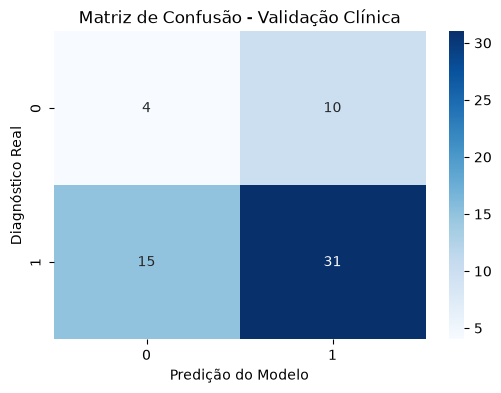

C:\Users\Reinaldo\AppData\Local\Temp\ipykernel_21060\3073552854.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Feature', data=df_importancia, palette='viridis')


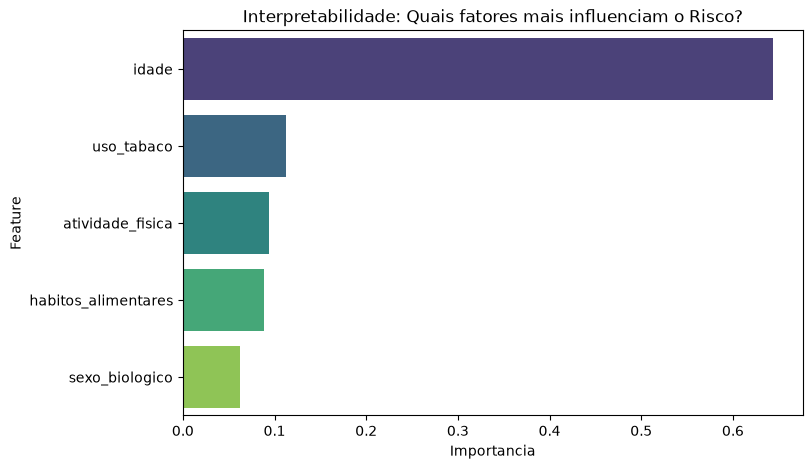

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Matriz de Confusão para validar os Falsos Negativos
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Validação Clínica')
plt.ylabel('Diagnóstico Real')
plt.xlabel('Predição do Modelo')
plt.show()

# Extração da Importância das Variáveis (Feature Importance)
importancias = best_rf.feature_importances_
features = X_train.columns
df_importancia = pd.DataFrame({'Feature': features, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importancia', y='Feature', data=df_importancia, palette='viridis')
plt.title('Interpretabilidade: Quais fatores mais influenciam o Risco?')
plt.show()

In [6]:
import streamlit as st
import numpy as np

st.title("Fapam MaisVida Preditivo 🩺")
st.subheader("Triagem Inteligente de Comorbidades em Idosos")

# Interface de Entrada para a Agente de Saúde
idade = st.slider("Idade do Paciente", 60, 110, 70)
sexo = st.selectbox("Sexo Biológico", ["Masculino", "Feminino"])
tabagismo = st.selectbox("Histórico de Tabagismo", ["Nunca fumou", "Ex-fumante", "Fumante ativo"])
atividade = st.selectbox("Frequência de Atividade Física", ["Sedentário", "1 a 2x/semana", "3+ vezes/semana"])
alimentacao = st.selectbox("Qualidade da Alimentação", ["Inadequada", "Regular", "Adequada"])

# Transformação dos inputs (simulação do pré-processamento)
# ... (código de mapeamento de strings para números inteiros) ...

if st.button("Calcular Probabilidade de Risco"):
    # Invocação do modelo treinado (best_rf)
    # predicao = best_rf.predict_proba(dados_paciente)[0][1]
    
    st.info("Processando dados do e-Sus...")
    st.success(f"Probabilidade de Risco Atual: ALTO (Alerta de Triagem Recomendado)")
    st.caption("Fatores determinantes para este paciente: Idade e Tabagismo Ativo.")

2026-07-11 21:29:17.094 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-11 21:29:18.425 
  command:

    streamlit run c:\Users\Reinaldo\OneDrive\Rei\IMAGE TI\DataScience\Projeto Aplicado\diagnostico_60mais\.venv\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-07-11 21:29:18.425 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-11 21:29:18.426 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-11 21:29:18.427 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-11 21:29:18.429 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-11 21:29:18.430 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when 